# **Лабораторна робота №3 “Кластеризація”**

<p>Виконала студентка ІІ-го курсу</p>
<p>Басовська Марія, групи КН-43</p>

---

<font size="5">**Мета**</font>

Ознайомитися з методами **кластеризації** (clustering) на прикладі реального набору музичних даних **Spotify Tracks Dataset**. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя **(elbow)**, виконувати кластеризацію методом **K-Means**, знижувати розмірність простору ознак за допомогою **PCA** для візуалізації та аналізувати характеристики утворених кластерів.

---

<font size="5">**Інструменти**</font>

Python: pandas, numpy, scikit-learn (PCA), matplotlib, plotly, seaborn, plotly.express; Jupyter Notebook

---

<font size="5">**Хід роботи**</font>

<font size="4">**1.Завантаження та підготовка даних**</font>

На першому етапі було завантажено набір даних Spotify Tracks Dataset у середовище Python за допомогою бібліотеки pandas. Для первинного ознайомлення з даними було виведено перші кілька рядків таблиці, що дозволило оцінити структуру датасету, а також виконано обчислення основних статистичних характеристик числових ознак (середнє значення, стандартне відхилення, мінімум, максимум тощо).

Оскільки алгоритм K-Means є чутливим до масштабу ознак, було виконано стандартизацію числових даних за допомогою методу StandardScaler з бібліотеки scikit-learn. Це дозволило привести всі ознаки до єдиного масштабу.

Для спрощення подальшої візуалізації було виконано фільтрацію даних — залишено лише ті треки, значення популярності яких становить не менше 85. Це дозволило зменшити кількість точок на графіках та зробити результати більш наочними.

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv((r'C:\Users\irgtb\Downloads\SpotifyFeatures.csv'))

print(df.head())

print(df.describe())

numeric_cols = df.select_dtypes(include=np.number).columns
X = df[numeric_cols]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_popular = df[df['popularity'] >= 85]

print("Розмір після фільтрації:", df_popular.shape)

   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       137373   0.737             0.000  F#

<font size="4">**2. Підбір оптимальної кількості кластерів (k) — метод ліктя**</font>

<p>На другому етапі було застосовано метод ліктя (Elbow Method) для визначення оптимальної кількості кластерів. Для цього було побудовано кілька моделей K-Means із різною кількістю кластерів (від 2 до 15).

Для кожної моделі було обчислено інерцію — суму квадратів відстаней від точок до центрів їхніх кластерів. Отримані значення було візуалізовано у вигляді графіка залежності інерції від кількості кластерів.

Аналіз графіка дозволив визначити точку "перелому" (лікоть), після якої зменшення інерції стає менш суттєвим. Саме це значення і було обрано як оптимальну кількість кластерів.</p>

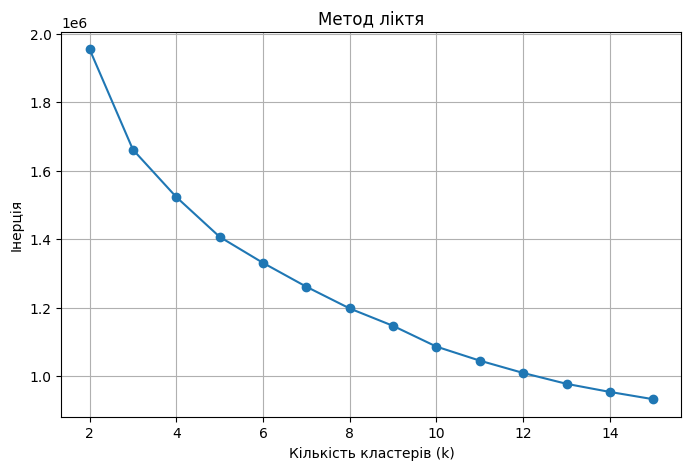

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Інерція")
plt.title("Метод ліктя")
plt.grid()
plt.show()

<font size="4">**3. Побудова кластеризації**</font>

Після визначення оптимального значення k було виконано кластеризацію даних за допомогою алгоритму K-Means. У результаті кожному треку було присвоєно мітку кластера.

Отримані мітки було додано до початкового DataFrame у вигляді нової колонки cluster. Також було підраховано кількість об'єктів у кожному кластері, що дозволило оцінити розподіл даних між кластерами.

In [12]:
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

print(df['cluster'].value_counts())

cluster
0    133030
2     57158
1     32317
3     10220
Name: count, dtype: int64


<font size="4">**4. Візуалізація кластерів у просторі головних компонент**</font>

Оскільки дані мають велику кількість ознак, для їх візуалізації було застосовано метод головних компонент (PCA), який дозволяє зменшити розмірність простору ознак із мінімальною втратою інформації.

Дані було зведено до двох (або трьох) головних компонент, після чого побудовано графік розсіювання. Кожна точка на графіку відповідає окремому треку, а колір точки визначається її кластером.

Для покращення читабельності візуалізації використовувалися лише треки з високим рівнем популярності (≥ 85). 

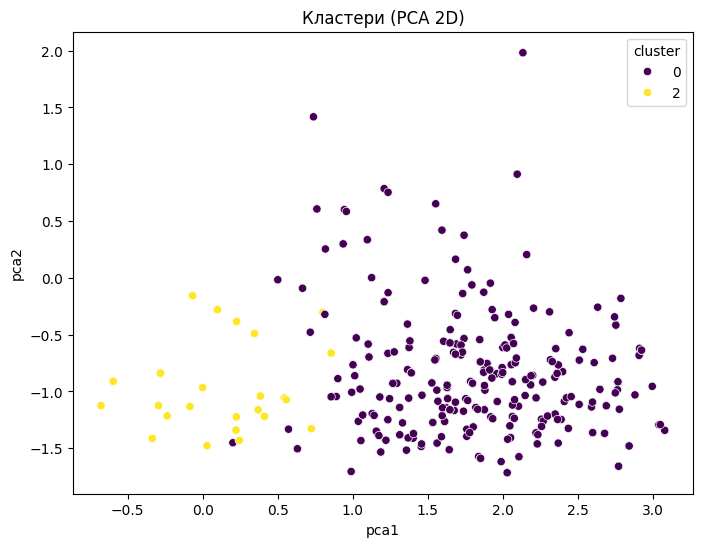

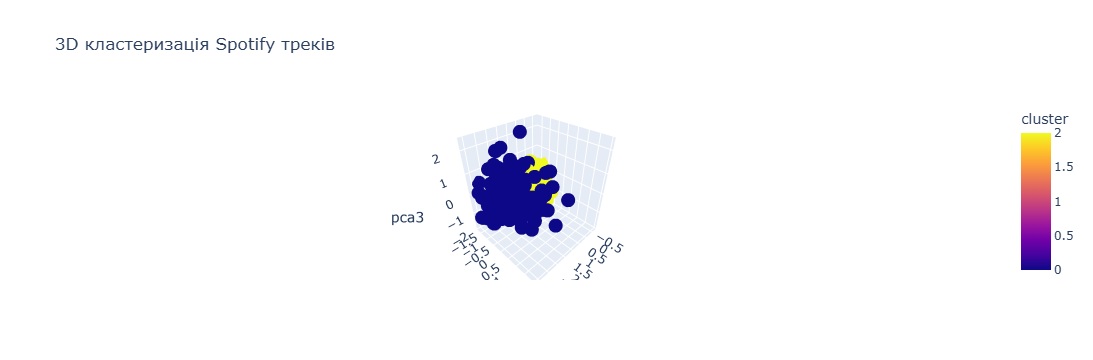

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

df_plot = df[df['popularity'] >= 85]

import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_plot,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='viridis'
)
plt.title("Кластери (PCA 2D)")
plt.show()

import plotly.express as px

pca = PCA(n_components=3)
X_pca3 = pca.fit_transform(X_scaled)

df['pca1'] = X_pca3[:, 0]
df['pca2'] = X_pca3[:, 1]
df['pca3'] = X_pca3[:, 2]

df_plot = df[df['popularity'] >= 85]

fig = px.scatter_3d(
    df_plot,
    x='pca1',
    y='pca2',
    z='pca3',
    color='cluster',
    title="3D кластеризація Spotify треків"
)

fig.show()

<font size="4">**5. Аналіз кластерів**</font>

На завершальному етапі було проведено аналіз отриманих кластерів. Для кожного кластера було обчислено середні значення основних числових ознак, що дозволило виявити характерні риси кожної групи.

Результати було представлено у вигляді таблиці та теплової карти (heatmap), що значно спростило порівняння кластерів між собою.

         popularity  acousticness  danceability    duration_ms    energy  \
cluster                                                                    
0         46.883583      0.120711      0.614557  232171.766481  0.738879   
1         26.144475      0.859527      0.291617  258646.933657  0.163486   
2         39.849715      0.592460      0.561554  227197.194164  0.394308   
3         20.727397      0.790003      0.561493  243464.397358  0.661623   

         instrumentalness  liveness   loudness  speechiness       tempo  \
cluster                                                                   
0                0.063954  0.208700  -6.178513     0.101779  124.493808   
1                0.629640  0.160114 -20.514940     0.048295  102.580650   
2                0.098724  0.168745 -10.836977     0.071564  113.769237   
3                0.001431  0.729472 -12.017876     0.872227   98.299789   

          valence  
cluster            
0        0.551619  
1        0.155464  
2        0.4

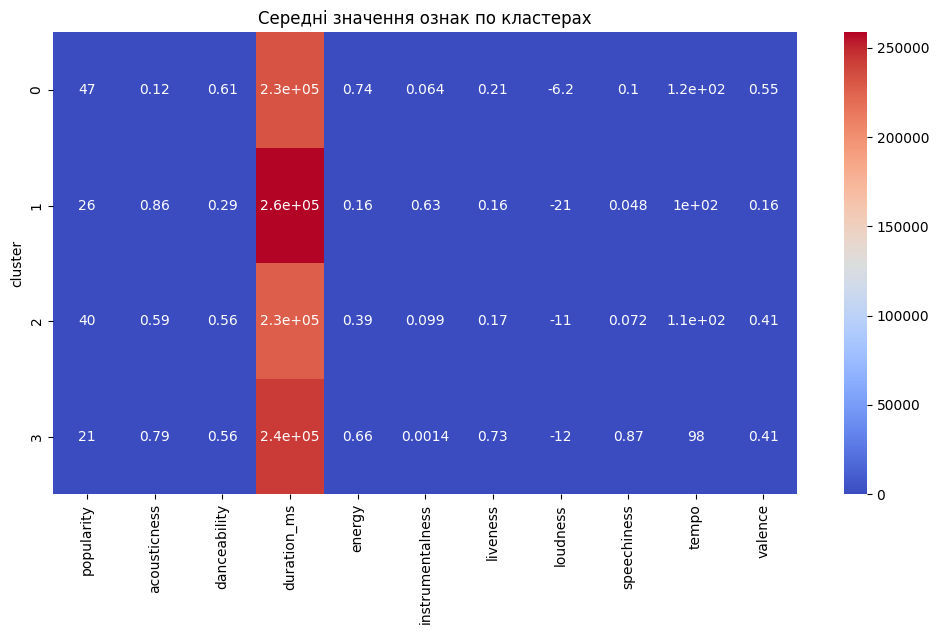

In [14]:
cluster_stats = df.groupby('cluster')[numeric_cols].mean()
print(cluster_stats)

plt.figure(figsize=(12,6))
sns.heatmap(cluster_stats, annot=True, cmap="coolwarm")
plt.title("Середні значення ознак по кластерах")
plt.show()

---

<font size="5">**Висновок**</font>

<p>У ході виконання роботи було досліджено методи кластеризації даних на прикладі реального музичного датасету. Було успішно застосовано алгоритм K-Means для групування треків за їх характеристиками.

За допомогою методу ліктя визначено оптимальну кількість кластерів, що забезпечує баланс між точністю моделі та її складністю. Використання методу головних компонент (PCA) дозволило ефективно візуалізувати багатовимірні дані у двовимірному та тривимірному просторі.

Отримані результати показали, що кластеризація дозволяє виявляти приховані закономірності в музичних даних та групувати треки за подібними характеристиками. Це може бути корисним для побудови рекомендаційних систем, аналізу музичних вподобань користувачів та дослідження структури музичного контенту.</p>